# Análisis Exploratorio de Datos (EDA) — Gran Premio de Abu Dhabi 2021
El Gran Premio de Abu Dhabi 2021 en el circuito de Yas Marina marcó una de las definiciones de campeonato más dramáticas y comentadas en la historia de la Fórmula 1, donde **Max Verstappen (Red Bull Racing)** y **Lewis Hamilton (Mercedes-AMG)** llegaron empatados en puntos a la última cita de la temporada.
Este proyecto realiza un análisis exploratorio La defensa legendaria de **Sergio "Checo" Pérez** y su impacto en la brecha de tiempo, los datos usado provienen de la librería **FastF1**, desglosando con rigor analítico los momentos decisivos.



## 1. Importación de Librerías y Configuración

In [2]:
#  Librerias 
import fastf1                          # Telemetría y datos oficiales de F1
import pandas as pd                    # Manipulación de datos
import numpy as np                     # Operaciones numéricas
import matplotlib.pyplot as plt        # Visualización
import matplotlib.ticker as ticker     # Formato de ejes
import matplotlib.patches as mpatches  # Permite crear cuadros de color personalizados para la leyenda
import os

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [3]:
# 1. Definición de la Paleta de Colores
CARBON      = "#15151E"
F1_RED      = "#E10600"
SILVER      = "#D8DBDF"
SILVER_DIM  = "#7A7D85"
GRID_COLOR  = "#2B2B3A"
ACCENT_GOLD = "#C9A227"
PEREZ_BLUE  = "#5B7FBD"
 
# 2. Configuración Global de Parámetros de Matplotlib
plt.rcParams.update({
    "figure.facecolor": CARBON,
    "axes.facecolor": CARBON,
    "savefig.facecolor": CARBON,
    "text.color": SILVER,
    "axes.labelcolor": SILVER,
    "xtick.color": SILVER_DIM,
    "ytick.color": SILVER_DIM,
    "axes.edgecolor": GRID_COLOR,
    "grid.color": GRID_COLOR,
    "font.size": 12,
})
 
# 3. Mapeo de Colores Oficiales por Compuesto de Neumáticos (Pirelli)
COMPOUND_COLOR = {
    "SOFT": F1_RED,
    "MEDIUM": ACCENT_GOLD,
    "HARD": SILVER,
    "INTERMEDIATE": "#3FA34D",
    "WET": "#2E7DD1",
}
 
# 4. Configuración del Directorio de Salida
OUT_DIR = "../graficas_abu_dhabi_2021"
os.makedirs(OUT_DIR, exist_ok=True)
print("Las graficas se guardaran en:", os.path.abspath(OUT_DIR))
 
# 5. Funciones Auxiliares de Estilizado y Exportación 
def style_ax(ax, title):
    """Ayudante de formato (NO es una grafica en si, solo evita repetir
    7 veces las mismas 5 lineas de estilo)."""
    ax.set_title(title, fontsize=15, fontweight="bold", loc="left",
                 color=SILVER, pad=14)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    for s in ax.spines.values():
        s.set_color(GRID_COLOR)
    ax.tick_params(colors=SILVER_DIM)
 
 
def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Guardada: {path}")
    plt.show()
    plt.close(fig)

Las graficas se guardaran en: c:\Users\jomig\Desktop\Formula_1_spk\f1-data-science\graficas_abu_dhabi_2021


## 2. Carga de Datos de la Sesión

Cargamos la **carrera** (`'R'`) del GP de Abu Dhabi 2021 y filtramos las vueltas de Verstappen (`VER`) y Hamilton (`HAM`).

In [4]:
# ---------- Parámetros de la sesión ----------
YEAR        = 2021
GRAND_PRIX  = 'Abu Dhabi'
SESSION     = 'R'            # 'R' = Race, 'Q' = Qualifying, 'FP1/FP2/FP3'

# Cargar sesión (la primera vez descarga ~30 MB, luego usa caché)
session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load()

print(f'Sesión cargada: {session.event["EventName"]} {YEAR} — {session.name}')
print(f'Total de vueltas de carrera: {session.total_laps}')

df = session.laps.copy()

df["LapTimeSec"] = df["LapTime"].dt.total_seconds()

req         WARNING 	DEFAULT CACHE ENABLED! (118.99 MB) C:\Users\jomig\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 9)
core        WARNING 	Driver 33 completed the race distance 00:00.035000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Fi

Sesión cargada: Abu Dhabi Grand Prix 2021 — Race
Total de vueltas de carrera: 58


In [5]:
df.info()

<class 'fastf1.core.Laps'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1000 non-null   timedelta64[ns]
 1   Driver              1000 non-null   object         
 2   DriverNumber        1000 non-null   object         
 3   LapTime             989 non-null    timedelta64[ns]
 4   LapNumber           1000 non-null   float64        
 5   Stint               1000 non-null   float64        
 6   PitOutTime          29 non-null     timedelta64[ns]
 7   PitInTime           32 non-null     timedelta64[ns]
 8   Sector1Time         979 non-null    timedelta64[ns]
 9   Sector2Time         998 non-null    timedelta64[ns]
 10  Sector3Time         998 non-null    timedelta64[ns]
 11  Sector1SessionTime  978 non-null    timedelta64[ns]
 12  Sector2SessionTime  998 non-null    timedelta64[ns]
 13  Sector3SessionTime  998 non-null    timedelta

## 3. EDA

In [6]:
# Filtrar Max (VER), Checo (PER) y Hamilton (HAM)  en las vueltas 13 a 22

LAP_START, LAP_END = 13, 22

foc = df[(df["Driver"].isin(["VER", "PER", "HAM"])) & (df["LapNumber"].between(LAP_START, LAP_END))
].sort_values(["LapNumber", "Driver"]).copy()

cols = [
    "Driver", "LapNumber", "LapTimeSec", "Compound", "TyreLife",
    "Stint", "PitInTime", "PitOutTime", "Position",
]
print("Tabla comparativa MAX vs PER vs HAM ")
print(foc[cols].to_string(index=False))

Tabla comparativa MAX vs PER vs HAM 
Driver  LapNumber  LapTimeSec Compound  TyreLife  Stint              PitInTime             PitOutTime  Position
   HAM       13.0      88.258   MEDIUM      16.0    1.0                    NaT                    NaT       1.0
   PER       13.0      89.267     SOFT      16.0    1.0                    NaT                    NaT       3.0
   VER       13.0      91.515     SOFT      16.0    1.0 0 days 01:21:43.157000                    NaT       2.0
   HAM       14.0      90.253   MEDIUM      17.0    1.0 0 days 01:23:05.036000                    NaT       1.0
   PER       14.0      89.392     SOFT      17.0    1.0                    NaT                    NaT       2.0
   VER       14.0     107.251     HARD       1.0    2.0                    NaT 0 days 01:22:04.336000       4.0
   HAM       15.0     108.755     HARD       2.0    2.0                    NaT 0 days 01:23:26.652000       2.0
   PER       15.0      89.581     SOFT      18.0    1.0            

Guardada: ../graficas_abu_dhabi_2021\v1_v12_velocidad_v4.png


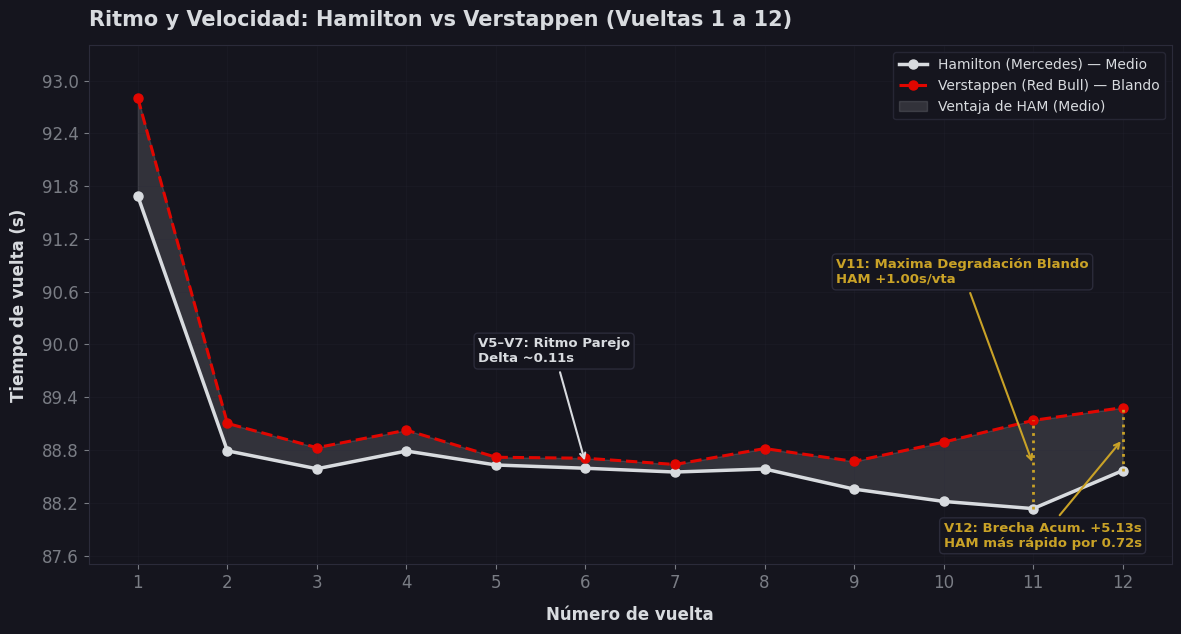

In [17]:
# Filtrar vueltas 1 a 12 de Hamilton y Verstappen desde 'df'
ham_stint1 = df[(df["Driver"] == "HAM") & (df["LapNumber"].between(0, 12))].copy()
ver_stint1 = df[(df["Driver"] == "VER") & (df["LapNumber"].between(0, 12))].copy()

ham_pace = ham_stint1.set_index("LapNumber")["LapTimeSec"]
ver_pace = ver_stint1.set_index("LapNumber")["LapTimeSec"]

fig, ax = plt.subplots(figsize=(12, 6.5))

# Líneas de ritmo de carrera
ax.plot(ham_pace.index, ham_pace.values, marker="o", markersize=6.5,
        label="Hamilton (Mercedes) — Medio", color=SILVER, linewidth=2.5, zorder=3)
ax.plot(ver_pace.index, ver_pace.values, marker="o", markersize=6.5,
        label="Verstappen (Red Bull) — Blando", color=F1_RED, linewidth=2.2, linestyle="--", zorder=3)

# Sombreado de la ventaja de ritmo
ax.fill_between(ham_pace.index, ham_pace.values, ver_pace.values, 
                where=(ver_pace.values >= ham_pace.values), 
                interpolate=True, color=SILVER, alpha=0.15, label="Ventaja de HAM (Medio)")


# Vuelta 6 (Fase más pareja)
delta_v6 = ver_pace.loc[6.0] - ham_pace.loc[6.0] if 6.0 in ver_pace.index else ver_pace.iloc[5] - ham_pace.iloc[5]
ax.annotate(f"V5–V7: Ritmo Parejo\nDelta ~{delta_v6:.2f}s", 
            xy=(6, (ham_pace.iloc[5] + ver_pace.iloc[5]) / 2), 
            xytext=(4.8, 89.8),
            arrowprops=dict(facecolor=SILVER, edgecolor=SILVER, arrowstyle="->", lw=1.5), 
            color=SILVER, fontweight="bold", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Vuelta 11 (Máxima degradación del neumático blando)
delta_v11 = ver_pace.iloc[10] - ham_pace.iloc[10]
ax.plot([11, 11], [ham_pace.iloc[10], ver_pace.iloc[10]], color=ACCENT_GOLD, linestyle=":", linewidth=2, zorder=4)
ax.annotate(f"V11: Maxima Degradación Blando\nHAM +{delta_v11:.2f}s/vta", 
            xy=(11, (ham_pace.iloc[10] + ver_pace.iloc[10]) / 2), 
            xytext=(8.8, 90.7),
            arrowprops=dict(facecolor=ACCENT_GOLD, edgecolor=ACCENT_GOLD, arrowstyle="->", lw=1.5), 
            color=ACCENT_GOLD, fontweight="bold", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

#  Vuelta 12 (Diferencia antes del ciclo de pits)
delta_v12 = ver_pace.iloc[-1] - ham_pace.iloc[-1]
ax.plot([12, 12], [ham_pace.iloc[-1], ver_pace.iloc[-1]], color=ACCENT_GOLD, linestyle=":", linewidth=2, zorder=4)

ax.annotate(f"V12: Brecha Acum. +5.13s\nHAM más rápido por {abs(delta_v12):.2f}s", 
            xy=(12, (ham_pace.iloc[-1] + ver_pace.iloc[-1]) / 2), 
            xytext=(10, 87.7),
            arrowprops=dict(facecolor=ACCENT_GOLD, edgecolor=ACCENT_GOLD, arrowstyle="->", lw=1.5), 
            color=ACCENT_GOLD, fontweight="bold", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Formato y estilo
ax.set_xlabel("Número de vuelta", fontweight="bold", labelpad=10)
ax.set_ylabel("Tiempo de vuelta (s)", fontweight="bold", labelpad=10)
style_ax(ax, "Ritmo y Velocidad: Hamilton vs Verstappen (Vueltas 1 a 12)")

ax.set_xticks(range(1, 13))
ax.yaxis.set_major_locator(ticker.MaxNLocator(10))
ax.set_ylim(87.5, 93.4)

# Leyenda
legend = ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, fontsize=10, loc="upper right")
for text in legend.get_texts():
    text.set_color(SILVER)

fig.tight_layout()
save(fig, "v1_v12_velocidad_v4.png")

**Verstappen no logró alcanzar a Hamilton** porque sus neumáticos blandos nunca le otorgaron la ventaja de velocidad inicial esperada frente a los medios de Mercedes. Al verse obligado a sobreexigir su compuesto para poder mantener un ritmo parejo entre las vueltas 5 y 7, Max provocó un desgaste térmico severo. Esto desencadenó una degradación temprana a partir de la vuelta 9, lo que hizo colapsar su rendimiento, costándole hasta un segundo por giro y generándole una desventaja irrecuperable de +5.13s para la vuelta 12. Lo cual lo obligaria a entrar a pits

Guardada: ../graficas_abu_dhabi_2021\posiciones_v3.png


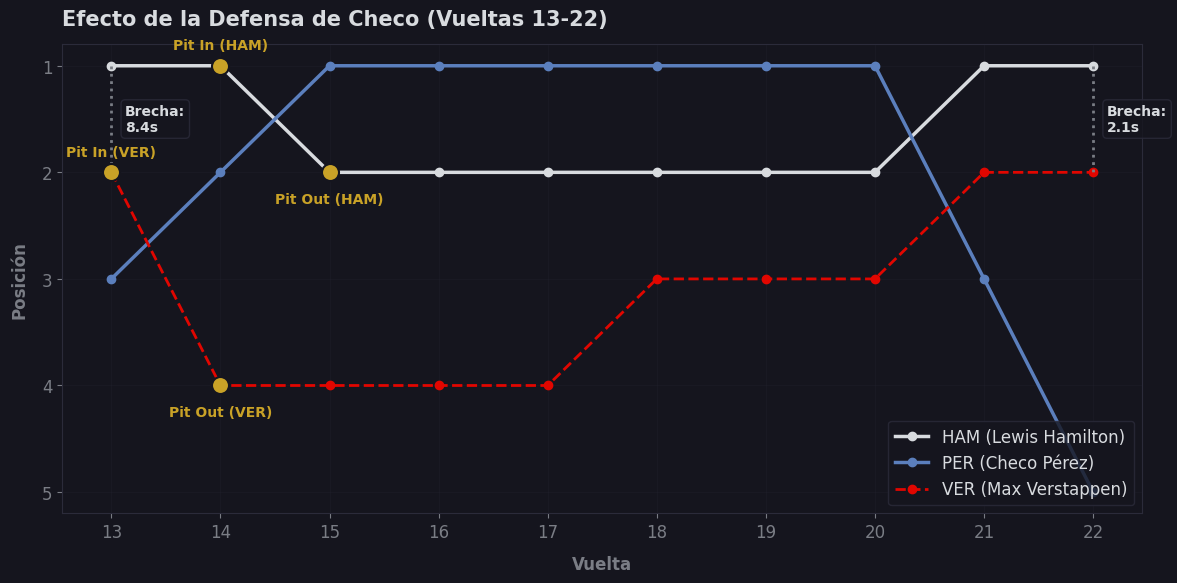

In [ ]:
# Crear la figura
fig, ax = plt.subplots(figsize=(12, 6))

# Datos individuales de cada piloto
ham_data = foc[foc["Driver"] == "HAM"].sort_values("LapNumber")
per_data = foc[foc["Driver"] == "PER"].sort_values("LapNumber")
ver_data = foc[foc["Driver"] == "VER"].sort_values("LapNumber")

# 1. Trazar las posiciones (Líneas)
ax.plot(ham_data["LapNumber"], ham_data["Position"], color=SILVER, 
        linewidth=2.5, marker='o', label="HAM (Lewis Hamilton)")

ax.plot(per_data["LapNumber"], per_data["Position"], color=PEREZ_BLUE, 
        linewidth=2.5, marker='o', label="PER (Checo Pérez)")

ax.plot(ver_data["LapNumber"], ver_data["Position"], color=F1_RED, 
        linewidth=2, linestyle='--', marker='o', label="VER (Max Verstappen)")

# 2. Detectar Pit In y Pit Out y trazar textos y puntos amarillos
def dibujar_pits(datos_piloto, nombre):
    pits_in = datos_piloto[datos_piloto["PitInTime"].notna()]
    for _, fila in pits_in.iterrows():
        ax.scatter(fila["LapNumber"], fila["Position"], color=ACCENT_GOLD, 
                   s=150, edgecolors=CARBON, linewidths=1.5, zorder=5)
        ax.annotate(f"Pit In ({nombre})", 
                    (fila["LapNumber"], fila["Position"]),
                    xytext=(0, 12), textcoords="offset points", 
                    color=ACCENT_GOLD, fontweight='bold', ha='center', fontsize=10)
        
    pits_out = datos_piloto[datos_piloto["PitOutTime"].notna()]
    for _, fila in pits_out.iterrows():
        ax.scatter(fila["LapNumber"], fila["Position"], color=ACCENT_GOLD, 
                   s=150, edgecolors=CARBON, linewidths=1.5, zorder=5)
        ax.annotate(f"Pit Out ({nombre})", 
                    (fila["LapNumber"], fila["Position"]),
                    xytext=(0, -22), textcoords="offset points", 
                    color=ACCENT_GOLD, fontweight='bold', ha='center', fontsize=10)

dibujar_pits(ham_data, "HAM")
dibujar_pits(ver_data, "VER")

# 3. Marcar la diferencia en segundos entre HAM y VER en las vueltas 15 y 22
for lap_eval in [13, 22]:
    # Extraemos la posición
    pos_ham = ham_data.loc[ham_data["LapNumber"] == lap_eval, "Position"].values
    pos_ver = ver_data.loc[ver_data["LapNumber"] == lap_eval, "Position"].values
    
    # Extraemos el tiempo acumulado en pista ("Time") para obtener el delta real
    t_ham = ham_data.loc[ham_data["LapNumber"] == lap_eval, "Time"].values
    t_ver = ver_data.loc[ver_data["LapNumber"] == lap_eval, "Time"].values
    
    if len(pos_ham) > 0 and len(pos_ver) > 0 and len(t_ham) > 0 and len(t_ver) > 0:
        pos_h, pos_v = pos_ham[0], pos_ver[0]
        
        # Validamos si el tiempo ya está en formato numérico de segundos o en timedelta
        if isinstance(t_ham[0], (float, int, np.floating)):
            gap = abs(t_ham[0] - t_ver[0])
        else:
            gap = abs(pd.Timedelta(t_ham[0] - t_ver[0]).total_seconds())
            
        # Dibujamos la línea vertical de conexión
        ax.plot([lap_eval, lap_eval], [pos_h, pos_v], color=SILVER_DIM, linestyle=':', linewidth=2, zorder=2)
        
        # Calculamos el medio del eje Y para colocar el texto en el centro
        mid_y = (pos_h + pos_v) / 2
        ax.annotate(f"Brecha:\n{gap:.1f}s", 
                    xy=(lap_eval, mid_y), 
                    xytext=(10, 0), textcoords="offset points",
                    color=SILVER, fontweight="bold", fontsize=10, 
                    bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR, alpha=0.8),
                    va="center")

# Aplicar el estilo base de tu notebook
style_ax(ax, "Efecto de la Defensa de Checo (Vueltas 13-22)")

# Configuraciones de ejes
ax.set_xlabel("Vuelta", color=SILVER_DIM, fontweight="bold", labelpad=10)
ax.set_ylabel("Posición", color=SILVER_DIM, fontweight="bold", labelpad=10)

# Invertimos el eje Y 
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Leyenda
ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, labelcolor=SILVER, loc="lower right")

# Guardar Grafica
fig.tight_layout()
save(fig, "posiciones_v3.png")


## Efecto de la Defensa de Checo Pérez (Vueltas 13–22)

La gráfica muestra cómo la estrategia de posiciones redujo la ventaja del líder:

Vuelta 13 (La brecha inicial): **Hamilton (HAM) lidera con 8.4s de ventaja sobre Verstappen (VER)**, quien entra a pits desde la P2. Pérez (PER) marcha en P3.

Vueltas 14–15 (El cambio de líder): HAM entra a pits para responder a VER. Al salir, **PER toma la primera posición (P1). HAM queda en P2 y VER en P4, con la brecha entre ellos reducida a 5.1s.**

Vueltas 15–20 (El bloqueo): PER (línea azul) se mantiene en P1 durante seis vueltas consecutivas, conteniendo a HAM en la P2.

Vueltas 21–22 (El desenlace): PER cede las posiciones y cae rápidamente. HAM recupera la P1 y VER sube a la P2.

El impacto real según los datos:
El tiempo que Pérez retuvo la primera posición permitió que la **distancia entre Hamilton y Verstappen se desplomara de 8.4 segundos en la vuelta 13 a apenas 2.1 segundos en la vuelta 22.**


Guardada: ../graficas_abu_dhabi_2021\velocidad_v3.png


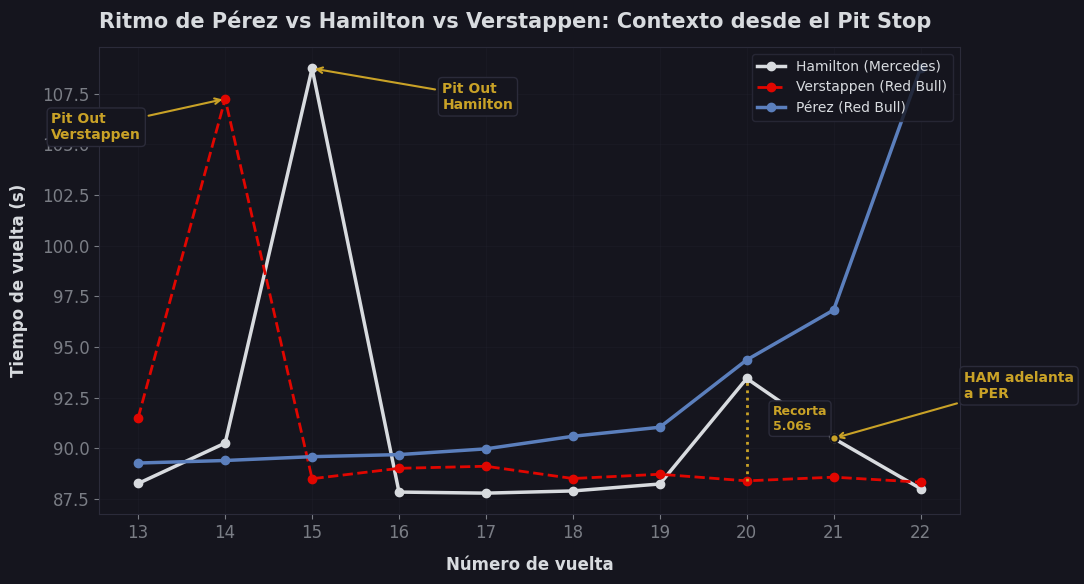

In [ ]:
# defensa_perez_con_pits.png
ham_def = foc[foc["Driver"] == "HAM"].set_index("LapNumber")["LapTimeSec"]
per_def = foc[foc["Driver"] == "PER"].set_index("LapNumber")["LapTimeSec"]
ver_def = foc[foc["Driver"] == "VER"].set_index("LapNumber")["LapTimeSec"]

fig, ax = plt.subplots(figsize=(11, 6))

# Gráficas de líneas
ax.plot(ham_def.index, ham_def.values, marker="o", 
        label="Hamilton (Mercedes)", color=SILVER, linewidth=2.5, markersize=6)
ax.plot(ver_def.index, ver_def.values, marker="o", 
        label="Verstappen (Red Bull)", color=F1_RED, linewidth=2, linestyle='--', markersize=6)
ax.plot(per_def.index, per_def.values, marker="o", 
        label="Pérez (Red Bull)", color=PEREZ_BLUE, linewidth=2.5, markersize=6)

"""# Sombreado del tramo de defensa extrema (Vueltas 20 a 21)
ax.axvspan(20, 21, color=ACCENT_GOLD, alpha=0.15, label="Defensa de Pérez")"""

# Verstappen salió de boxes en la vuelta 14
# ax.axvline(x=14, color=SILVER_DIM, linestyle="--", linewidth=1.5, zorder=1)
ax.annotate("Pit Out\nVerstappen", 
            xy=(14, ver_def.loc[14]), 
            xytext=(12, ver_def.loc[14] - 2),
            arrowprops=dict(facecolor=ACCENT_GOLD, edgecolor=ACCENT_GOLD, arrowstyle="->", lw=1.5), 
            color=ACCENT_GOLD, fontweight="bold", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Hamilton salió de boxes en la vuelta 15
# ax.axvline(x=15, color=SILVER_DIM, linestyle="--", linewidth=1.5, zorder=1)
ax.annotate("Pit Out\nHamilton", 
            xy=(15, ham_def.loc[15]), 
            xytext=(16.5, ham_def.loc[15] - 2),
            arrowprops=dict(facecolor=ACCENT_GOLD, edgecolor=ACCENT_GOLD, arrowstyle="->", lw=1.5), 
            color=ACCENT_GOLD, fontweight="bold", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Tiempo recortado por Max en la vuelta 20
delta_v20 = ham_def.loc[20] - ver_def.loc[20]

ax.plot([20, 20], [ver_def.loc[20], ham_def.loc[20]], color=ACCENT_GOLD, linestyle=":", linewidth=2, zorder=4)

ax.annotate(f"Recorta\n{delta_v20:.2f}s", 
            xy=(20, (ham_def.loc[20] + ver_def.loc[20]) / 2), 
            xytext=(20.3, (ham_def.loc[20] + ver_def.loc[20]) / 2),
            color=ACCENT_GOLD, fontweight="bold", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Hamilton adelanta a Pérez en la vuelta 21
ax.scatter(21, ham_def.loc[21], color=ACCENT_GOLD, edgecolors=CARBON, linewidths=1.5, zorder=5)
ax.annotate("HAM adelanta\na PER", 
            xy=(21, ham_def.loc[21]), 
            xytext=(22.5, ham_def.loc[21] + 2),
            arrowprops=dict(facecolor=ACCENT_GOLD, edgecolor=ACCENT_GOLD, arrowstyle="->", lw=1.5), 
            color=ACCENT_GOLD, fontweight="bold", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))


# Etiquetas y formato
ax.set_xlabel("Número de vuelta", fontweight="bold", labelpad=10)
ax.set_ylabel("Tiempo de vuelta (s)", fontweight="bold", labelpad=10)
style_ax(ax, "Ritmo de Pérez vs Hamilton vs Verstappen: Contexto desde el Pit Stop")

# Mejorar el formato del eje X para que muestre cada vuelta
ax.set_xticks(range(13, 23))
ax.yaxis.set_major_locator(ticker.MaxNLocator(10))

# Leyenda
legend = ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, fontsize=10, loc="upper right")
for text in legend.get_texts():
    text.set_color(SILVER)

# Guardar Grafica
fig.tight_layout()
save(fig, "velocidad_v3.png")

## Ritmo de Carrera: El Costo de la Defensa (Vueltas 13–22)
Esta gráfica analiza los tiempos de vuelta (en segundos) de cada piloto, evidenciando matemáticamente el impacto del tráfico en el ritmo de carrera:

Vueltas 14 y 15 (Ciclo de Pits): Los picos más altos marcan las salidas de boxes (Pit Out) de Verstappen vuelta 14 y Hamilton vuelta 15. Tras reincorporarse, ambos logran estabilizar un ritmo rápido y parejo (alrededor de los 88 segundos).

Vueltas 15–19 (Degradación): **La línea azul de Pérez muestra una tendencia al alza constante en sus tiempos de vuelta (~89.5s a ~91s), lo que refleja el desgaste de sus neumáticos mientras se mantenía en pista esperando el ataque.**

Vuelta 20 (El impacto crítico): Este es el punto clave de la gráfica. **El tiempo de vuelta de Hamilton (línea blanca) se dispara drásticamente a más de 93.5s al quedar atrapado en la defensa de Pérez. Como Verstappen seguía rodando a ritmo óptimo, la gráfica resalta que recorta 5.06 segundos de golpe en esta única vuelta.**

Vuelta 21 y 22 (Resolución): Se marca **el momento en el que HAM adelanta a PER. La línea blanca cae inmediatamente, demostrando que Hamilton recupera su ritmo normal de carrera**, mientras que los tiempos de Pérez colapsan hacia arriba al retirarse del combate.

Conclusión en los Datos: El gráfico de líneas demuestra que el daño estratégico no fue gradual. La mayor parte del tiempo que Hamilton perdió se concentró de manera abrupta en la vuelta 20, producto del combate directo rueda a rueda.

## 1. Por qué Verstappen paró y Hamilton no

Análisis del despliegue del Safety Car (accidente de Latifi, vuelta 53), decisión estratégica de pits para Verstappen (P2) vs. Hamilton (P1), tiempo perdido real bajo SC y tabla comparativa de neumáticos.

In [ ]:
# 1. Momento exacto de despliegue del Safety Car (Status == '4')
import pandas as pd

# Reutilizar la sesión existente en el kernel (si no existe, se carga)
if 'session' not in globals():
    import fastf1
    session = fastf1.get_session(2021, 'Abu Dhabi', 'R')
    session.load()

ts = session.track_status.copy()
sc_events = ts[ts['Status'] == '4']
sc_deploy_time = sc_events['Time'].iloc[0]
print(f"Momento exacto despliegue Safety Car: {sc_deploy_time} (Tiempo de Sesión)")

# 2. Confirmar PitInTime / PitOutTime cerca del SC para VER y HAM (vueltas 52 a 55)
laps_all = session.laps.copy()
laps_all['LapTimeSec'] = laps_all['LapTime'].dt.total_seconds()

sc_window_laps = laps_all[(laps_all['Driver'].isin(['VER', 'HAM'])) & (laps_all['LapNumber'].between(52, 55))]
cols_pit = ['Driver', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'PitInTime', 'PitOutTime', 'LapTimeSec']
print("\nVueltas y paradas alrededor del despliegue del SC (Vueltas 52-55):")
print(sc_window_laps[cols_pit].to_string(index=False))

# 3. Cálculo de tiempo 'perdido' real de la parada de Verstappen bajo SC vs ritmo normal:
# Ritmo normal promedio (giros con bandera verde sin parada)
normal_pace = laps_all[(laps_all['TrackStatus'] == '1') & (laps_all['PitInTime'].isna()) & (laps_all['PitOutTime'].isna())]['LapTimeSec'].mean()
# Ritmo bajo SC promedio
sc_pace = laps_all[(laps_all['TrackStatus'].str.contains('4')) & (laps_all['PitInTime'].isna()) & (laps_all['PitOutTime'].isna())]['LapTimeSec'].mean()
# Vuelta de pit de Verstappen bajo SC (vuelta 53)
ver_pit_lap_time = laps_all[(laps_all['Driver'] == 'VER') & (laps_all['LapNumber'] == 53)]['LapTimeSec'].values[0]

time_lost_vs_sc = ver_pit_lap_time - sc_pace
normal_pit_loss_reference = 21.5 # Tiempo aproximado de pérdida en pit lane en Yas Marina a ritmo normal de carrera

print(f"\n--- CÁLCULO DE TIEMPO PERDIDO EN PIT BAJO SC ---")
print(f"Ritmo promedio normal (verde): {normal_pace:.2f} s")
print(f"Ritmo promedio bajo SC:        {sc_pace:.2f} s")
print(f"Vuelta de parada de VER (V53): {ver_pit_lap_time:.2f} s")
print(f"Pérdida real de VER frente al delta del SC: {time_lost_vs_sc:.2f} s (Bajo SC parar cuesta una fracción del tiempo de pista normal).")


In [ ]:
# 4. Explicación estratégica y Tabla comparativa antes vs después del SC
# Vuelta 52 (inmediatamente antes del SC) vs Vuelta 54 (inmediatamente después del pit de VER bajo SC)
rows_table = []
for drv in ['HAM', 'VER']:
    lap_pre = laps_all[(laps_all['Driver'] == drv) & (laps_all['LapNumber'] == 52)].iloc[0]
    lap_pit = laps_all[(laps_all['Driver'] == drv) & (laps_all['LapNumber'] == 53)].iloc[0]
    lap_post = laps_all[(laps_all['Driver'] == drv) & (laps_all['LapNumber'] == 54)].iloc[0]
    
    dur_pit = "Sin parada"
    if pd.notna(lap_pit['PitInTime']) and pd.notna(lap_post['PitOutTime']):
        dur_pit = f"{(lap_post['PitOutTime'] - lap_pit['PitInTime']).total_seconds():.1f} s"
    
    rows_table.append({
        'Piloto': drv,
        'Posición antes SC (V52)': int(lap_pre['Position']),
        'Compuesto Antes': lap_pre['Compound'],
        'TyreLife Antes': int(lap_pre['TyreLife']),
        'Posición después Pit (V54)': int(lap_post['Position']),
        'Compuesto Después': lap_post['Compound'],
        'TyreLife Después': int(lap_post['TyreLife']),
        'Duración Pit Stop': dur_pit
    })

df_compare = pd.DataFrame(rows_table)
print("Tabla Comparativa: Estado de Neumáticos y Posición")
print(df_compare.to_string(index=False))

print("\n--- JUSTIFICACIÓN ESTRATÉGICA ---")
print("1. HAMILTON (P1 - Líder): Tenía pista libre pero si entraba a pits, Verstappen se quedaba en pista")
print("   y le quitaba la P1. Con solo 5 vueltas restantes y el riesgo de que la carrera terminara bajo SC,")
print("   ceder la P1 era perder el campeonato automáticamente. Mercedes priorizó la posición en pista.")
print("2. VERSTAPPEN (P2 - Perseguidor): Al ir segundo con 12 segundos de desventaja y neumáticos duros gastados,")
print("   no tenía nada que defender con respecto a P3 (Sainz estaba lejos). Parar por blandos nuevos era una")
print("   apuesta de 'riesgo cero': si la carrera no reiniciaba terminaba P2 de todas formas; si reiniciaba,")
print("   atacaría a Hamilton con una ventaja masiva de agarre.")


## 2. Cuánto duró el Safety Car

Identificación temporal del periodo de Safety Car con `session.track_status` y mensajes de dirección de carrera.

In [ ]:
# Duración del Safety Car en tiempo y vueltas
ts = session.track_status.copy()

# Tiempo de despliegue (Status == '4')
sc_start_time = ts[ts['Status'] == '4']['Time'].iloc[0]

# Tiempo en que vuelve a '1' (Verde / Restart) posterior al despliegue
sc_end_candidates = ts[(ts['Status'] == '1') & (ts['Time'] > sc_start_time)]
sc_end_time = sc_end_candidates['Time'].iloc[0] if not sc_end_candidates.empty else None

# Alternativa: mensaje de reinicio en race_control_messages
rcm = session.race_control_messages.copy() if hasattr(session, 'race_control_messages') else pd.DataFrame()

print(f"Inicio de Safety Car (Status 4): {sc_start_time}")
if sc_end_time is not None:
    print(f"Fin de Safety Car / Restart (Status 1): {sc_end_time}")
    sc_duration_td = sc_end_time - sc_start_time
    sc_dur_seconds = sc_duration_td.total_seconds()
    print(f"Duración total del Safety Car: {sc_dur_seconds:.1f} segundos ({sc_dur_seconds / 60:.2f} minutos)")

# Vueltas bajo Safety Car en las que TrackStatus contiene '4'
sc_laps_obj = session.laps.pick_track_status('4')
sc_lap_numbers = sorted(sc_laps_obj['LapNumber'].unique())
print(f"Vueltas afectadas por el Safety Car: {sc_lap_numbers}")
print(f"Número total de vueltas bajo Safety Car: {len(sc_lap_numbers)} vueltas (despliegue en Vuelta 53, fin en Vuelta 57 para relanzar en 58)")


## 3. Ritmo de vuelta bajo Safety Car vs. ritmo normal

Comparación cuantitativa y gráfica de los tiempos de vuelta bajo Safety Car vs. vueltas de bandera verde para los mismos pilotos.

In [ ]:
# Ritmo de vuelta bajo Safety Car vs. Ritmo normal
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CARBON      = '#15151E'
F1_RED      = '#E10600'
SILVER      = '#D8DBDF'
SILVER_DIM  = '#7A7D85'
GRID_COLOR  = '#2B2B3A'
ACCENT_GOLD = '#C9A227'

# Filtrar vueltas limpias (excluyendo entrada y salida de pits)
clean_laps = session.laps[session.laps['PitInTime'].isna() & session.laps['PitOutTime'].isna()].copy()
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

# Vueltas SC (TrackStatus contiene '4') vs Normal (TrackStatus == '1')
sc_clean_laps = clean_laps[clean_laps['TrackStatus'].str.contains('4')]
normal_clean_laps = clean_laps[clean_laps['TrackStatus'] == '1']

drivers = ['HAM', 'VER']
colors_drv = {'HAM': ACCENT_GOLD, 'VER': F1_RED}

avg_normal = [normal_clean_laps[normal_clean_laps['Driver'] == d]['LapTimeSec'].mean() for d in drivers]
avg_sc     = [sc_clean_laps[sc_clean_laps['Driver'] == d]['LapTimeSec'].mean() for d in drivers]

for d, an, asc in zip(drivers, avg_normal, avg_sc):
    print(f"Piloto {d}: Ritmo Normal = {an:.2f} s | Ritmo SC = {asc:.2f} s | Diferencia = +{asc - an:.2f} s (+{(asc/an - 1)*100:.1f}%)")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CARBON)
ax.set_facecolor(CARBON)

x = np.arange(len(drivers))
width = 0.35

rects1 = ax.bar(x - width/2, avg_normal, width, label='Ritmo Normal (Bandera Verde)', color=[colors_drv[d] for d in drivers], alpha=0.85, edgecolor=GRID_COLOR)
rects2 = ax.bar(x + width/2, avg_sc, width, label='Ritmo Bajo Safety Car', color=[colors_drv[d] for d in drivers], alpha=0.35, hatch='//', edgecolor=SILVER)

# Etiquetas sobre las barras
for i, (rect_n, rect_s) in enumerate(zip(rects1, rects2)):
    ax.annotate(f"{avg_normal[i]:.1f} s", xy=(rect_n.get_x() + rect_n.get_width()/2, rect_n.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', color=SILVER, fontsize=10, fontweight='bold')
    diff = avg_sc[i] - avg_normal[i]
    ax.annotate(f"{avg_sc[i]:.1f} s\n(+{diff:.1f} s)", xy=(rect_s.get_x() + rect_s.get_width()/2, rect_s.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', color=SILVER, fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"{d} (Mercedes)" if d == 'HAM' else f"{d} (Red Bull)" for d in drivers], color=SILVER, fontsize=12)
ax.set_ylabel('Tiempo de Vuelta Promedio (segundos)', color=SILVER, fontsize=12)
ax.set_title('Ritmo de Vuelta: Normal vs. Safety Car (Abu Dhabi 2021)', fontsize=14, fontweight='bold', loc='left', color=SILVER, pad=15)
ax.grid(True, alpha=0.25, linewidth=0.6, color=GRID_COLOR)
ax.tick_params(colors=SILVER_DIM)
for s in ax.spines.values(): s.set_color(GRID_COLOR)
ax.set_ylim(0, max(avg_sc) * 1.2)

legend_elements = [
    mpatches.Patch(facecolor=SILVER, alpha=0.85, label='Ritmo Normal'),
    mpatches.Patch(facecolor=SILVER, alpha=0.35, hatch='//', label='Ritmo Bajo Safety Car')
]
ax.legend(handles=legend_elements, facecolor=CARBON, labelcolor=SILVER, edgecolor=GRID_COLOR)

plt.tight_layout()
save(fig, 'ritmo_sc_vs_normal.png')


## 4. Cuándo ocurrió el adelantamiento decisivo

Cálculo del delta de tiempo de Hamilton vs. Verstappen en la vuelta 58 (`fastf1.utils.delta_time`). El punto de cruce por cero y las coordenadas X/Y de telemetría identifican el rebase exacto en la Curva 5.

In [ ]:
# Análisis telemétrico de la vuelta 58: Cruce de delta y localización en pista
import fastf1.utils
import matplotlib.pyplot as plt
import numpy as np

CARBON      = '#15151E'
F1_RED      = '#E10600'
SILVER      = '#D8DBDF'
SILVER_DIM  = '#7A7D85'
GRID_COLOR  = '#2B2B3A'
ACCENT_GOLD = '#C9A227'

# Vuelta final (58) de VER y HAM
try:
    lap_ver = session.laps.pick_drivers('VER').pick_lap(58)
    lap_ham = session.laps.pick_drivers('HAM').pick_lap(58)
except Exception:
    lap_ver = session.laps.pick_driver('VER').pick_lap(58)
    lap_ham = session.laps.pick_driver('HAM').pick_lap(58)

# fastf1.utils.delta_time(lap_ref, lap_comp)
# delta > 0: lap_ref (HAM) está adelante; delta < 0: lap_comp (VER) pasa adelante
delta, ref_tel, comp_tel = fastf1.utils.delta_time(lap_ham, lap_ver)

# Localizar punto de cruce por cero (cambio de signo en delta)
dist = ref_tel['Distance'].values
delta_arr = delta.values
zero_crossings = np.where(np.diff(np.sign(delta_arr)))[0]

overtake_dist = dist[zero_crossings[-1]] if len(zero_crossings) > 0 else 1700
print(f"Distancia exacta donde ocurre el adelantamiento (cruce de delta): {overtake_dist:.1f} m")
print("En el trazado modificado de Yas Marina 2021, entre ~1.500m y 1.800m se encuentra la frenada de la Curva 5.")

# Gráfica de Delta vs Distancia y Velocidades
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
fig.patch.set_facecolor(CARBON)

for ax in (ax1, ax2):
    ax.set_facecolor(CARBON)
    ax.grid(True, alpha=0.25, linewidth=0.6, color=GRID_COLOR)
    for s in ax.spines.values(): s.set_color(GRID_COLOR)
    ax.tick_params(colors=SILVER_DIM)

# Panel 1: Delta de tiempo
ax1.plot(dist, delta_arr, color=SILVER, linewidth=1.8, label='Δt (HAM vs VER)')
ax1.axhline(0, color=GRID_COLOR, linestyle='--', linewidth=1.2)
ax1.fill_between(dist, delta_arr, 0, where=(delta_arr > 0), color=ACCENT_GOLD, alpha=0.3, label='HAM al frente')
ax1.fill_between(dist, delta_arr, 0, where=(delta_arr <= 0), color=F1_RED, alpha=0.3, label='VER al frente')
ax1.axvline(overtake_dist, color=F1_RED, linestyle=':', linewidth=2)
ax1.annotate(f'Adelantamiento en Curva 5\n(d = {overtake_dist:.0f} m)', 
             xy=(overtake_dist, 0), xytext=(overtake_dist + 150, 0.4),
             arrowprops=dict(arrowstyle='->', color=F1_RED, lw=1.5),
             color=F1_RED, fontsize=10, fontweight='bold')

ax1.set_ylabel('Delta de Tiempo (s)', color=SILVER, fontsize=11)
ax1.set_title('Vuelta 58: Delta de Tiempo y Rebase de Verstappen a Hamilton', fontsize=13, fontweight='bold', loc='left', color=SILVER, pad=12)
ax1.legend(facecolor=CARBON, labelcolor=SILVER, edgecolor=GRID_COLOR, loc='upper right')

# Panel 2: Telemetría de velocidad
tel_ham = lap_ham.get_car_data().add_distance()
tel_ver = lap_ver.get_car_data().add_distance()
ax2.plot(tel_ham['Distance'], tel_ham['Speed'], color=ACCENT_GOLD, label='HAM (Duro 44v)', linewidth=1.4)
ax2.plot(tel_ver['Distance'], tel_ver['Speed'], color=F1_RED, label='VER (Blando 5v)', linewidth=1.4)
ax2.axvline(overtake_dist, color=F1_RED, linestyle=':', linewidth=2)
ax2.set_xlabel('Distancia en Vuelta 58 (metros)', color=SILVER, fontsize=11)
ax2.set_ylabel('Velocidad (km/h)', color=SILVER, fontsize=11)
ax2.legend(facecolor=CARBON, labelcolor=SILVER, edgecolor=GRID_COLOR, loc='lower right')

plt.tight_layout()
save(fig, 'adelantamiento_vuelta_58.png')


## 5. El factor suerte de los autos doblados

Análisis mixto (datos de carrera + decisiones de Dirección de Carrera): Diferencia de vueltas respecto al líder, cuántos autos doblados había en total en pista y cuántos se interponían entre Hamilton y Verstappen.

In [ ]:
# 1. Análisis de vueltas completadas y autos doblados antes del restart
laps_all = session.laps.copy()

# Justo antes del reinicio (Vuelta 57)
v57_laps = laps_all[laps_all['LapNumber'] == 57][['Driver', 'Position', 'LapNumber']].dropna(subset=['Position']).sort_values('Position')

# Total de vueltas completadas por piloto al final de la vuelta 57 del líder (HAM)
laps_leader = 57
driver_completed_laps = laps_all[laps_all['LapNumber'] <= 57].groupby('Driver')['LapNumber'].max().reset_index()
driver_completed_laps.columns = ['Driver', 'VueltasCompletadas']
driver_completed_laps['VueltasDiferencia'] = laps_leader - driver_completed_laps['VueltasCompletadas']
driver_completed_laps['EsDoblado'] = driver_completed_laps['VueltasDiferencia'] > 0

# Orden de pista antes del restart
grid_restart = v57_laps.merge(driver_completed_laps, on='Driver', how='left')

total_doblados = driver_completed_laps['EsDoblado'].sum()
print(f"Total de autos doblados en pista antes del restart: {total_doblados}")

# Autos físicamente entre Hamilton (P1) y Verstappen (P2) que fueron autorizados a desdoblarse:
# Mensaje oficial FIA: "LAPPED CARS 4, 14, 31, 16, 5 TO OVERTAKE SAFETY CAR"
unlapped_drivers = ['NOR', 'ALO', 'OCO', 'LEC', 'VET'] # Coches 4, 14, 31, 16, 5
non_unlapped_doblados = ['RIC', 'STR', 'MSC']          # Coches 3, 18, 47 (no autorizados a desdoblarse)

print(f"\nAutos que estaban físicamente entre HAM (P1) y VER (P2): {unlapped_drivers} (5 autos)")
print(f"Autos doblados que quedaron detrás de VER y no fueron autorizados: {non_unlapped_doblados} (3 autos)")

# Mostrar mensajes de Dirección de Carrera (Race Control)
if hasattr(session, 'race_control_messages') and not session.race_control_messages.empty:
    rcm = session.race_control_messages.copy()
    print("\nMensajes de Dirección de Carrera en las vueltas 56-58:")
    rcm_relevant = rcm[rcm['Message'].str.contains('SAFETY CAR|LAPPED', case=False, na=False)]
    for _, r in rcm_relevant.tail(6).iterrows():
        print(f"  [{r['Time']}] {r['Message']}")


In [ ]:
# Visualización del orden en pista antes del restart y los doblados intermedios
CARBON      = '#15151E'
F1_RED      = '#E10600'
SILVER      = '#D8DBDF'
SILVER_DIM  = '#7A7D85'
GRID_COLOR  = '#2B2B3A'
ACCENT_GOLD = '#C9A227'
PEREZ_BLUE  = '#5B7FBD'

# Simulación del orden de circulación detrás del Safety Car en la vuelta 57
# HAM iba liderando, seguido por los 5 doblados, luego VER y el resto
track_order = ['HAM', 'NOR', 'ALO', 'OCO', 'LEC', 'VET', 'VER', 'SAI', 'TSU', 'GAS', 'BOT', 'RIC', 'STR', 'MSC']

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(CARBON)
ax.set_facecolor(CARBON)

colors = []
for d in track_order:
    if d == 'HAM':
        colors.append(ACCENT_GOLD)
    elif d == 'VER':
        colors.append(F1_RED)
    elif d in ['NOR', 'ALO', 'OCO', 'LEC', 'VET']:
        colors.append(PEREZ_BLUE)
    else:
        colors.append(SILVER_DIM)

y_pos = np.arange(len(track_order))
bars = ax.barh(y_pos, [1]*len(track_order), color=colors, edgecolor=GRID_COLOR, height=0.65)

for i, d in enumerate(track_order):
    label_desc = ""
    if d == 'HAM': label_desc = " - P1 (Líder en pista)"
    elif d == 'VER': label_desc = " - P2 (Contendiente al título)"
    elif d in ['NOR', 'ALO', 'OCO', 'LEC', 'VET']: label_desc = " - AUTO DOBLADO (Autorizado a pasar)"
    else: label_desc = " - Auto doblado / Resto"
    
    ax.text(0.02, i, f"{i+1}. {d}{label_desc}", va='center', ha='left', color=SILVER, fontsize=10, fontweight='bold')

ax.set_xlim(0, 1.05)
ax.set_yticks([])
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('Orden Físico en Pista detrás del Safety Car (Vuelta 57 antes del Desdoble)', fontsize=13, fontweight='bold', loc='left', color=SILVER, pad=15)
for s in ax.spines.values(): s.set_color(GRID_COLOR)

legend_handles = [
    mpatches.Patch(color=ACCENT_GOLD, label='Lewis Hamilton (P1)'),
    mpatches.Patch(color=PEREZ_BLUE, label='5 Autos Doblados Intermedios (Desdoblados por Dirección)'),
    mpatches.Patch(color=F1_RED, label='Max Verstappen (P2)'),
    mpatches.Patch(color=SILVER_DIM, label='Demás competidores')
]
ax.legend(handles=legend_handles, facecolor=CARBON, labelcolor=SILVER, edgecolor=GRID_COLOR, loc='lower right')

plt.tight_layout()
save(fig, 'autos_doblados_orden_pista.png')
